# Module 1 Notebook B: Overfitting vs Underfitting From Scratch

This notebook builds polynomial regression manually using NumPy to show:
- underfitting
- good fit
- overfitting

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)
plt.rcParams['figure.figsize'] = (8, 4)

## 1) Nonlinear Dataset

Ground truth is a smooth nonlinear function.

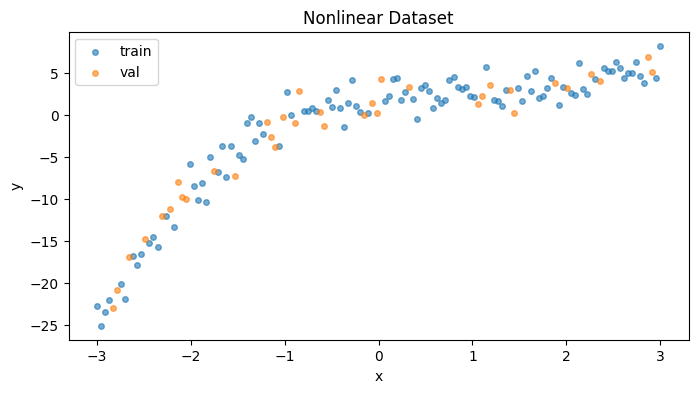

In [2]:
X = np.linspace(-3, 3, 140)
y_true = 0.5 * X**3 - 1.2 * X**2 + X + 2
noise = np.random.normal(0, 1.5, size=X.shape)
y = y_true + noise

# train/validation split (manual)
idx = np.random.permutation(len(X))
cut = int(0.75 * len(X))
train_idx, val_idx = idx[:cut], idx[cut:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]

plt.scatter(X_train, y_train, s=16, alpha=0.6, label='train')
plt.scatter(X_val, y_val, s=16, alpha=0.6, label='val')
plt.title('Nonlinear Dataset')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## 2) Polynomial Features and Closed-Form Fit

In [3]:
def poly_features(x, degree):
    x = np.asarray(x)
    return np.column_stack([x**d for d in range(degree + 1)])


def fit_linear_closed_form(X_design, y, reg=1e-8):
    # Ridge-like tiny regularization for numerical stability
    I = np.eye(X_design.shape[1])
    return np.linalg.inv(X_design.T @ X_design + reg * I) @ X_design.T @ y


def predict(X_design, w):
    return X_design @ w


def mse(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

## 3) Degree Sweep

In [4]:
degrees = [1, 2, 3, 5, 9, 14]
train_mse, val_mse = [], []

for d in degrees:
    Phi_train = poly_features(X_train, d)
    Phi_val = poly_features(X_val, d)
    w = fit_linear_closed_form(Phi_train, y_train)

    train_pred = predict(Phi_train, w)
    val_pred = predict(Phi_val, w)

    train_mse.append(mse(y_train, train_pred))
    val_mse.append(mse(y_val, val_pred))

for d, tr, va in zip(degrees, train_mse, val_mse):
    print(f"degree={d:<2} | train MSE={tr:8.3f} | val MSE={va:8.3f}")

degree=1  | train MSE=  17.506 | val MSE=  15.491
degree=2  | train MSE=   5.491 | val MSE=   5.157
degree=3  | train MSE=   2.081 | val MSE=   2.055
degree=5  | train MSE=   2.031 | val MSE=   2.222
degree=9  | train MSE=   1.996 | val MSE=   2.413
degree=14 | train MSE=   1.847 | val MSE=   2.613


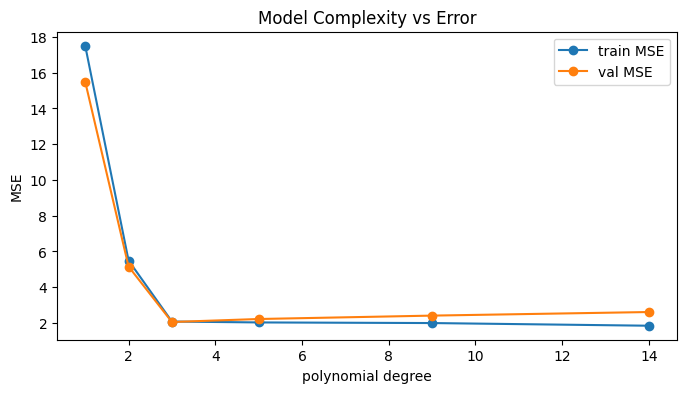

In [5]:
plt.plot(degrees, train_mse, marker='o', label='train MSE')
plt.plot(degrees, val_mse, marker='o', label='val MSE')
plt.title('Model Complexity vs Error')
plt.xlabel('polynomial degree')
plt.ylabel('MSE')
plt.legend()
plt.show()

## 4) Visualize Underfit/Good Fit/Overfit

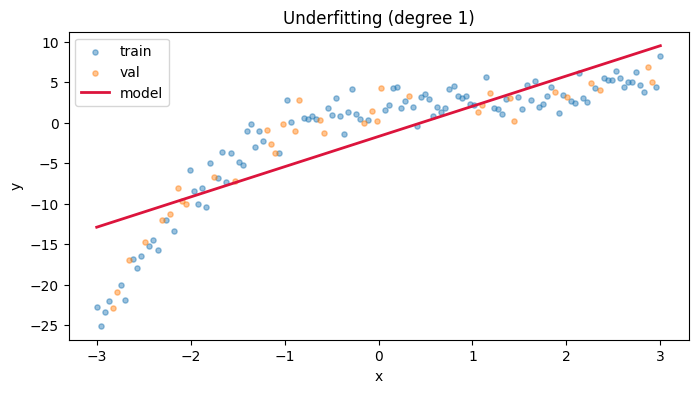

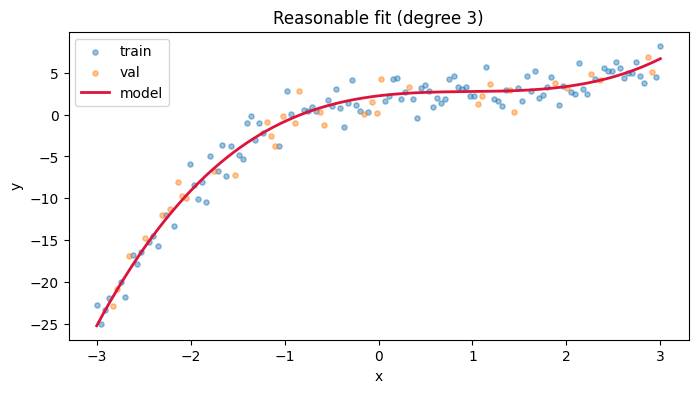

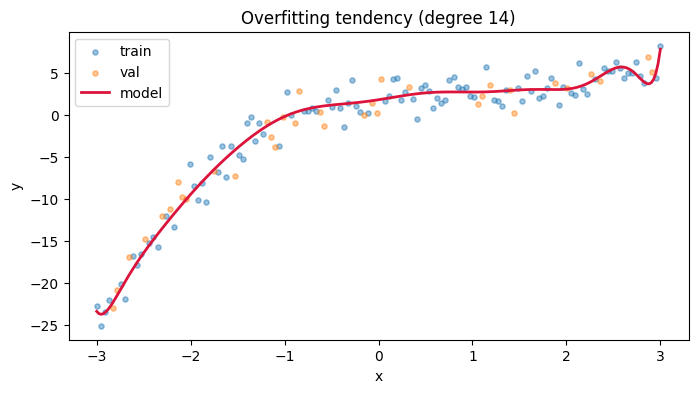

In [6]:
x_plot = np.linspace(-3, 3, 250)

for d, title in [(1, 'Underfitting (degree 1)'), (3, 'Reasonable fit (degree 3)'), (14, 'Overfitting tendency (degree 14)')]:
    w = fit_linear_closed_form(poly_features(X_train, d), y_train)
    y_plot = predict(poly_features(x_plot, d), w)

    plt.figure(figsize=(8, 4))
    plt.scatter(X_train, y_train, s=14, alpha=0.45, label='train')
    plt.scatter(X_val, y_val, s=14, alpha=0.45, label='val')
    plt.plot(x_plot, y_plot, color='crimson', linewidth=2, label='model')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()

## Practice

1. Add stronger regularization in `fit_linear_closed_form` and inspect high-degree behavior.
2. Repeat with a different random split and compare validation trends.
3. Add a feature scaling step and check numerical stability for high degree.